# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
helper_dir = '../src/tf_activity/'
sys.path.append(helper_dir)
from helper import adata_lambda, net_lambda, enrich_tfs
sys.path.append(helper_dir)

datasets = ['data1', 'data7_allTPs_jalil']

# - color palette
color_palette = sns.color_palette("tab10", len(datasets))  
datasets_colors = {label: color for label, color in zip(datasets, color_palette)}

# - load data
if False:
    cell_type = 'CD8T'
    adata_complete = {dataset: adata_lambda(dataset) for dataset in datasets}
    adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
    nets_dict = {dataset: net_lambda(dataset, cell_type) for dataset in datasets}
    tf_acts_dict = {}
    for dataset in datasets:
        tf_acts = enrich_tfs(adata_dict[dataset], nets_dict[dataset])
        tf_acts_dict[dataset] = tf_acts

# - pathways
helper_dir = '../'
sys.path.append(helper_dir)
from src.utils.util import get_canonical_pathways
pathways_df = get_canonical_pathways()

# - tf list 
tf_list = np.loadtxt('../../task_grn_inference/resources/grn_benchmark/prior/tf_all.csv', dtype=str)

# Run for all cell types

In [2]:
# import anndata as ad
# from src.tf_activity.helper import adata_lambda
# adata = adata_lambda('data1')
# adata_sub = adata[adata.obs['cell_type'].isin(['CD4T', 'CD8T'])]
# cols = adata_sub.obs.columns
# unique_cols = ['donor_id', 'age']
# other_cols = [col for col in cols if col not in unique_cols+['cell_type', 'cell_count', 'sum_by']]

# df = pd.DataFrame(
#     adata_sub.X.toarray() if hasattr(adata_sub.X, "toarray") else adata_sub.X,  # Convert sparse to dense if needed
#     columns=adata_sub.var_names,
#     index=pd.MultiIndex.from_frame(adata_sub.obs[unique_cols])  # Keep MultiIndex
# ).reset_index()  # Convert MultiIndex back to normal columns
# df = df.groupby(unique_cols).mean().dropna()
# adata_mean = ad.AnnData(X=df.values, obs=df.reset_index()[unique_cols], var=pd.DataFrame(index=df.columns))
# obs = adata_mean.obs.copy()
# adata_mean.obs = obs.merge(adata_sub.obs[unique_cols+other_cols], on=unique_cols, how='left').drop_duplicates().reset_index(drop=True)
# adata_mean.obs['cell_count'] = None
# adata_mean.obs['cell_type'] = 'T'

In [3]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import sys 
sys.path.append('../')
from src.tf_activity.script import main as main_tf_activity
import pandas as pd
import numpy as np

cell_types = ['T', 'CD4T', 'CD8T', 'NK', 'B', 'MONO']

par = {
    # - global vars
    'cell_type': 'MONO',
    'datasets': ['data1', 'data7_allTPs_jalil'], # data7_allTPs_jalil
    'central_tf_q': .8,
    'predictor_age_q': .8,
}

stats_df_store = []
for cell_type in cell_types:
    par['cell_type'] = cell_type
    stats_df = main_tf_activity(par)
    stats_df['cell_type'] = cell_type
    stats_df_store.append(stats_df)
stats_all = pd.concat(stats_df_store)
stats_all.to_csv('../output/tf_activation/stats_all.csv', index=False)

Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.68, Spearman: 0.79
Final Model R²: 0.91, Spearman: 0.95
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.67, Spearman: 0.79
Final Model R²: 0.92, Spearman: 0.95
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.61, Spearman: 0.75
Final Model R²: 0.84, Spearman: 0.91
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.40, Spearman: 0.64
Final Model R²: 0.72, Spearman: 0.85
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.43, Spearman: 0.65
Final Model R²: 0.71, Spearman: 0.84
Running central TFs analysis
Running age prediction analysis
Final Model R²: 0.43, Spearman: 0.62
Final Model R²: 0.75, Spearman: 0.88


## Discovery type overlap


In [4]:
if False:
    from matplotlib_venn import venn2, venn3
    import pandas as pd
    import matplotlib.pyplot as plt

    sys.path.append('../../')
    from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
    df = stats_all.copy()

    for cell_type in stats_all['cell_type'].unique():
        df = stats_all[stats_all['cell_type'] == cell_type]
        df = df.explode("type")[['tf', 'type']]
        df_dict = df.groupby(['type'])['tf'].apply(list).to_dict()
        interaction_df = create_interaction_df(df_dict)
        aa = plot_interactions(interaction_df)
        plt.title(f'Interaction between TFs and type {cell_type}', pad=40)

## Positive/negative trends, all cell types

<Axes: xlabel='cell_type', ylabel='Sig. TFs'>

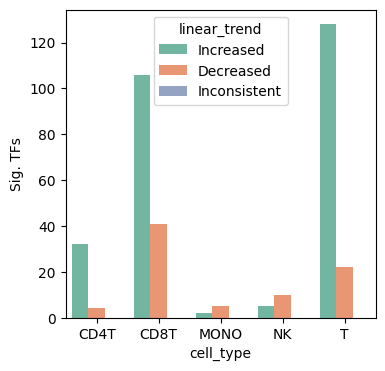

In [5]:
def add_supp_cols(df, pval_col='meta_p_value', slope_col='slope'):
    # Compute -log10(p_value_adj) for dot size
    df["neg_log10_adj_pval"] = -np.log10(df[pval_col])
    if 'linear_trend' in df.columns:
        df.drop('linear_trend', inplace=True, axis=1)
    # Determine color based on slope sign
    def determine_sign(x):
        if x.prod()<0:
            return "Inconsistent" 
        elif x.min() > 0:
            return "Increased"
        else:
            return "Decreased"
    linear_trend = df.groupby(['tf', 'cell_type'])[slope_col].apply(determine_sign).reset_index(name='linear_trend')
    linear_trend = linear_trend.dropna()

    # linear_trend = linear_trend[linear_trend.isna()]
 
    df = df.merge(linear_trend, on=['tf', 'cell_type'], how='left')
    df["linear_trend"] = pd.Categorical(
        df["linear_trend"], 
        categories=["Increased", "Decreased", "Inconsistent"], 
        ordered=True
    )
    return df

stats_all_sig = stats_all[stats_all['meta_p_value'] < 0.05]
stats_all_sig = add_supp_cols(stats_all_sig, pval_col='meta_p_value', slope_col='slope')
df = stats_all_sig[['tf', 'cell_type', 'meta_p_value', 'linear_trend', 'neg_log10_adj_pval']]
df = df[~df.duplicated()].reset_index(drop=True)
df_counts = df.groupby(['cell_type', 'linear_trend']).size().reset_index(name='Sig. TFs')
sns.barplot(data=df_counts, x='cell_type', y='Sig. TFs', hue='linear_trend', palette='Set2')

## Interaction of sig TFs between different cell types

['T', 'CD8T', 'CD4T', 'NK', 'MONO']


Text(0.5, 1.0, 'Interaction between TFs and cell types')

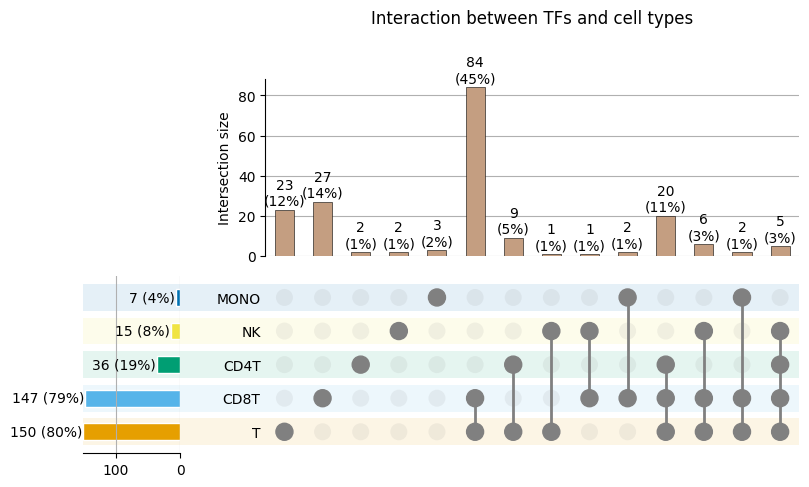

In [6]:
sys.path.append('../../')
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df
df = stats_all.copy()

df_dict = df.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_df = create_interaction_df(df_dict)
aa = plot_interactions(interaction_df)
plt.title('Interaction between TFs and cell types', pad=40)

## TF activity vs expression

In [7]:
df_act = add_supp_cols(stats_all_sig, pval_col='meta_p_value', slope_col='slope')[['tf', 'cell_type', 'meta_p_value', 'linear_trend', 'neg_log10_adj_pval']]
df_act = df_act[~df_act.duplicated()].reset_index(drop=True).dropna()
df_exp = add_supp_cols(stats_all_sig, pval_col='meta_p_value_expression', slope_col='slope_expression')[['tf', 'cell_type', 'meta_p_value', 'linear_trend', 'neg_log10_adj_pval']]
df_exp = df_exp[~df_exp.duplicated()].reset_index(drop=True).dropna()
df_act['type'] = 'Activation'
df_exp['type'] = 'Expression'
df = pd.concat([df_act, df_exp])
df_pivot = df.pivot(index=["tf", "cell_type"], columns="type", values="neg_log10_adj_pval").reset_index()
df_trend = df.groupby(["tf", "cell_type"])["linear_trend"].first().reset_index()
df_pivot = df_pivot.merge(df_trend, on=["tf", "cell_type"], how="left")
df_pivot.head(5)

,tf,cell_type,Activation,Expression,linear_trend
0,AIRE,CD4T,4.460019,2.596014,Increased
1,AIRE,T,20.371346,1.123219,Increased
2,ANXA1,CD4T,1.616657,6.213891,Increased
3,ANXA1,CD8T,15.974423,25.491769,Increased
4,ANXA1,NK,2.499188,0.837951,Increased


In [8]:
df_pivot['linear_trend'] = df_pivot['linear_trend'].astype(str)

In [9]:
from src.helper import determine_centrality

def lambda_centrality(cell_type, tfs):
    """
        for a given cell type, compute the centrality of the TFs in the network, averaged over the two datasets, and subsetted to the TFs of interest
    """
    net1 = net_lambda(datasets[0], cell_type)
    net2 = net_lambda(datasets[1], cell_type)

    net1_c = determine_centrality(net1, use_weight=False)
    net2_c = determine_centrality(net2, use_weight=False)

    net1_c['dataset'] = datasets[0]
    net2_c['dataset'] = datasets[1]

    c = pd.concat([net1_c, net2_c], axis=0)
    c = c[c.index.isin(tfs)]
    assert c.isna().any().any() == False
    c = c.reset_index().rename(columns={'index': 'tf'})
    c = c.groupby(['tf'])['centrality'].mean().reset_index()
    return c 


posx and posy should be finite values
posx and posy should be finite values


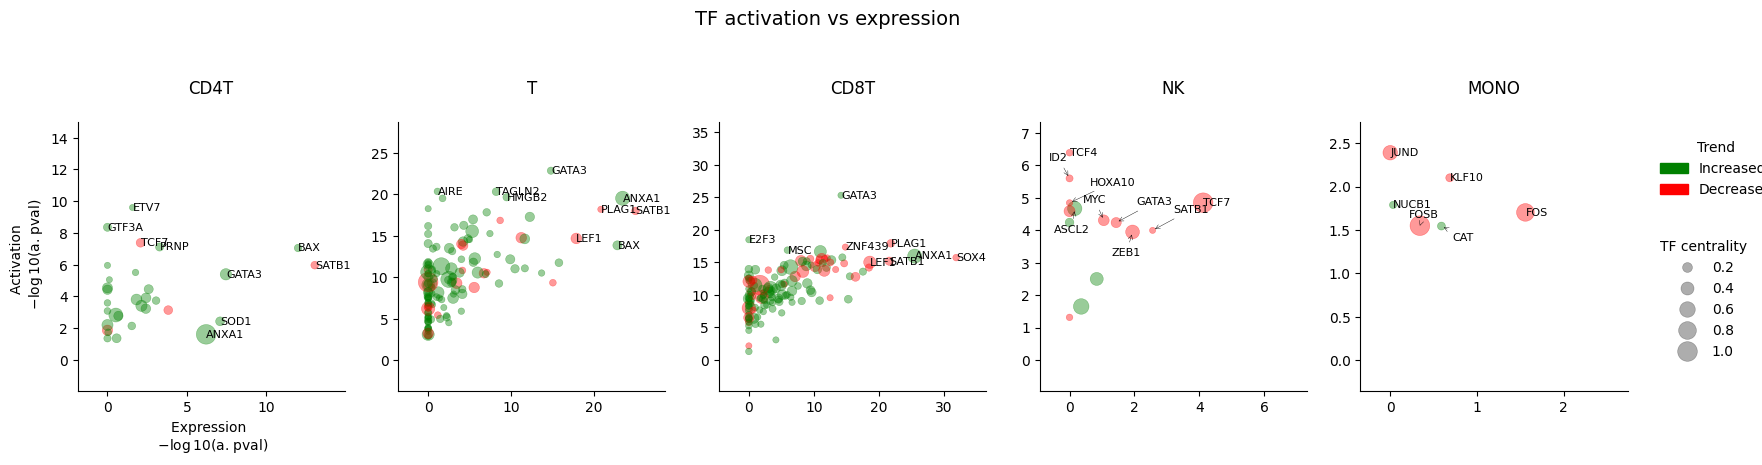

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cell_types = df_pivot["cell_type"].unique()
fig, axes = plt.subplots(1, len(cell_types), figsize=(20, 3.5), sharey=False, sharex=False)

# Define a consistent color mapping for linear_trend
unique_trends = df_pivot["linear_trend"].dropna().unique()
trend_colors = ["green", "red", "gray"]  # Adjust if needed
palette = {name: color for name, color in zip(unique_trends, trend_colors)}

for i, cell_type in enumerate(cell_types):
    ax = axes[i]
    df_cell_type = df_pivot[df_pivot["cell_type"] == cell_type]
    
    sig_tfs = df_cell_type['tf'].unique()
    c = lambda_centrality(cell_type, sig_tfs) 
    df_cell_type = df_cell_type.merge(c, on='tf', how='left')
    df_cell_type['centrality'] = df_cell_type['centrality'].div(df_cell_type['centrality'].max())

    # Plot scatter with correct color mapping
    sns.scatterplot(
        data=df_cell_type,
        x="Expression",
        y="Activation",
        palette=palette,  # Use the consistent color mapping
        size="centrality",
        hue="linear_trend",
        sizes=(20, 200),
        edgecolor=None,
        alpha=0.4,
        ax=ax,
    )

    # Annotate top central genes
    top_tfs_act = df_cell_type.nlargest(5, 'Activation')  # Adjust number if needed
    top_tfs_exp = df_cell_type.nlargest(5, 'Expression')  
    top_tfs = pd.concat([top_tfs_act, top_tfs_exp]).drop_duplicates()

    import numpy as np

    placed_positions = []
    for _, row in top_tfs.iterrows():
        x, y, label = row["Expression"], row["Activation"], row["tf"]

        # Default label position (slightly offset)
        label_x = x 
        label_y = y 

        # Check if the position is too close to existing labels
        too_close = any(
            np.linalg.norm([label_x - px, label_y - py]) < 0.07 * (global_max - global_min)
            for px, py in placed_positions
        )

        if too_close:
            # Use an arrow to move the label further if it's too close
            shift_x = 0.02 * (global_max - global_min)* np.random.choice([-1, 1])
            shift_y = 0.02 * (global_max - global_min) * np.random.choice([-1, 1])

            label_x = x + shift_x
            label_y = y + shift_y

            # Draw an arrow from the point to the label
            ax.annotate(label, 
                        xy=(x, y), 
                        xytext=(label_x, label_y), 
                        fontsize=8, ha='left', va='center', color='black',
                        arrowprops=dict(arrowstyle="->", lw=0.3, color="black"))  
        else:
            # Just place the text normally if it's not too close
            ax.text(label_x, label_y, label, fontsize=8, ha='left', va='center', color='black')

        # Store the new label position
        placed_positions.append((label_x, label_y))

    if i == 0:
        ax.set_xlabel("Expression \n $-\log{10}$(a. pval)")
        ax.set_ylabel("Activation \n $-\log{10}$(a. pval)")
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
    ax.get_legend().remove()  # Remove legend from individual plot

    ax.set_title(cell_type, pad=20)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_aspect("equal", adjustable="datalim")
    xmin, xmax = df_cell_type["Expression"].min(), df_cell_type["Expression"].max()
    ymin, ymax = df_cell_type["Activation"].min(), df_cell_type["Activation"].max()

    # Set the limits to be the same for both axes
    global_min = min(xmin, ymin)
    global_max = max(xmax, ymax)

    # Define padding as a percentage of the total range
    padding = 0.15 * (global_max - global_min)

    # Apply the same limits to both axes
    ax.set_xlim(global_min - padding, global_max + padding)
    ax.set_ylim(global_min - padding, global_max + padding)



handles, labels = ax.get_legend_handles_labels()
# Create color legend for linear_trend
color_legend = [mpatches.Patch(color=palette[name], label=name) for name in palette]
color_legend_handle = plt.legend(handles=color_legend, title='Trend', loc=(1.1, .7), frameon=False)

# Create size legend for TF centrality
size_legend_handle = plt.legend(handles=handles[-5:], labels=labels[-5:], title="TF centrality", 
                                loc=(1.1, .1),  frameon=False)

# Add the color legend manually after the size legend
plt.gca().add_artist(color_legend_handle)

plt.suptitle("TF activation vs expression", y=1.2, fontsize=14)
plt.show()

## Dotplot: expression- vs activation-based sig TFs 

Text(0.5, 0.95, 'Sig. TFs in ageing')

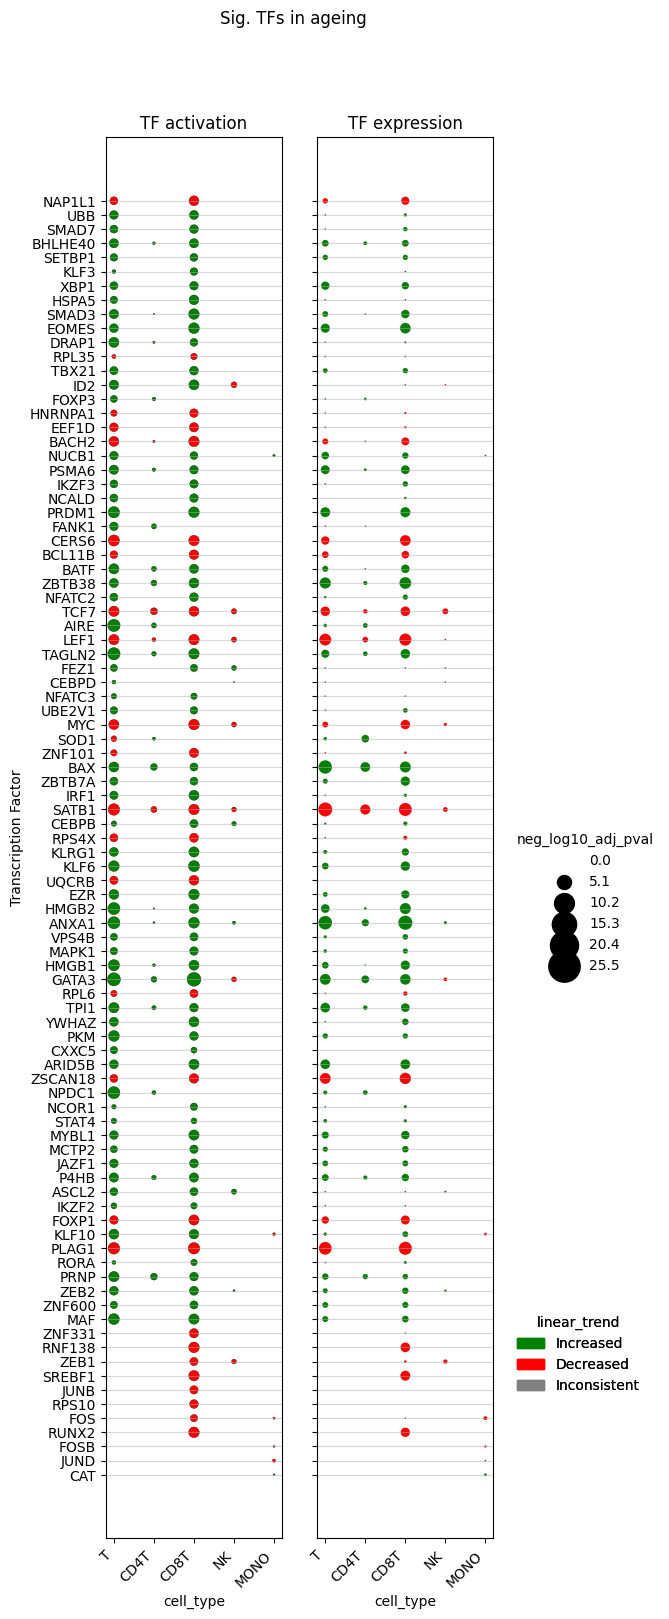

In [11]:
# - define a few functions 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def dotplot_tf_celltype(df, ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title=None):
    if color_col is not None:
        palette = {name: color for name, color in zip(df[color_col].cat.categories, ["green", "red", "gray"])}
        color_legend = [mpatches.Patch(color=color, label=name) for name, color in palette.items()]
    else:
        palette = "tab10"
        color_legend = []
    # Capture scatter plot object
    scatter = sns.scatterplot(
        data=df, 
        x="cell_type", 
        y="tf", 
        size=size_col, 
        hue=color_col, 
        sizes=(1, 100),
        palette=palette, 
        edgecolor="black",
        legend=False,  # Disable automatic legend
        ax=ax
    )
    # Labels and formatting
    ax.set_ylabel("Transcription Factor")
    # ax.set_xlabel("Cell type")
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    # 1. Create Color Legend 
    color_legend_handle = plt.legend(handles=color_legend, title=color_col, loc=(1.1, .1), frameon=False)

    # 2. Create Size Legend 
    size_legend_values = np.linspace(df[size_col].min() , df[size_col].max(), num=6)
    size_legend_handles = [plt.scatter([], [], s=s * 20, color="black", label=f"{s:.1f}") for s in size_legend_values]
    size_legend_handle = plt.legend(handles=size_legend_handles, title=size_col, loc=(1.1, .4), frameon=False)
    plt.gca().add_artist(color_legend_handle)

stats_all.reset_index(drop=True, inplace=True)
stats_all['cell_type'] = stats_all['cell_type'].astype('category')

if False: # subset to make the tf list shorter
    selected_tfs = stats_all_sig.loc[~stats_all_sig['cell_type'].isin(['CD8T', 'T']), 'tf'].unique()
elif True:
    discovery_type = stats_all_sig['type'].explode()
    index_central = discovery_type[discovery_type=='central'].index
    stats_all_sig_central = stats_all_sig[stats_all_sig.index.isin(index_central)]
    selected_tfs = stats_all_sig_central['tf'].unique()
else:
    selected_tfs = stats_all_sig['tf'].unique()

fig, axes = plt.subplots(1, 2, figsize=(5, len(selected_tfs)*.2), 
                         gridspec_kw={'width_ratios': [.2, .2]}, 
                         sharey=True)# - plot TF activation stats
i = 0

# - plot TF activation stats
ax = axes[i]
df_act = add_supp_cols(stats_all_sig, pval_col='meta_p_value', slope_col='slope')[['tf', 'cell_type', 'linear_trend', 'neg_log10_adj_pval']]
df_act = df_act[~df_act.duplicated()].reset_index(drop=True)
dotplot_tf_celltype(df_act[df_act['tf'].isin(selected_tfs)], ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title='TF activation')
ax.grid(axis='y', alpha=0.5)
ax.margins(y=0.05)
i+=1
# - plot TF exprssion stats

ax = axes[i]
df_exp = add_supp_cols(stats_all_sig, pval_col='meta_p_value_expression', slope_col='slope_expression')[['tf', 'cell_type', 'meta_p_value', 'linear_trend', 'neg_log10_adj_pval']]
df_exp = df_exp[~df_exp.duplicated()].reset_index(drop=True)
dotplot_tf_celltype(df_exp[df_exp['tf'].isin(selected_tfs)], ax, color_col='linear_trend', size_col='neg_log10_adj_pval', title='TF expression')
ax.grid(axis='y', alpha=0.5)
i+=1

plt.suptitle("Sig. TFs in ageing", y=.95)

In [12]:
# - plot pathway association
if False:
    fig, ax = plt.subplots(1, 1, figsize=(10, 35), 
                        #  gridspec_kw={'width_ratios': [.2, .2]}, 
                         sharey=True)# - plot TF activation stats
    i = 0
    # ax = axes[i]
    stats_all_sig_merged = stats_all_sig.merge(pathways_df, left_on='tf', right_index=True)
    df = stats_all_sig_merged
    pathway_order = df["pathway"].value_counts().index # Reverse order for left-heavy sorting
    sns.stripplot(data=df, x="pathway", y="tf", jitter=True, dodge=True, 
                    size=8, alpha=0.7, order=pathway_order, ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("Pathway Membership")
    ax.set_ylabel("Transcription Factor (TF)")
    ax.set_title("TF Membership in Pathways")
    ax.grid(axis='y', alpha=0.5)
    i+=1

# Trajectory plot: TF acitvity with age

In [13]:
from helper import plot_trends
if False:
    plot_trends(stats_df['tf'].unique(), datasets, tf_acts_dict, datasets_colors, cell_type, stats_df)

# GSEA

In [15]:
# remove those that were not consistent 
stats_all_sig = add_supp_cols(stats_all_sig, pval_col='meta_p_value', slope_col='slope')[['tf', 'cell_type', 'linear_trend', 'neg_log10_adj_pval']]

stats_all_sig_consistent = stats_all_sig[stats_all_sig['linear_trend'] != 'Inconsistent']
stats_all_sig_consistent.head(5)

,tf,cell_type,linear_trend,neg_log10_adj_pval
0,NAP1L1,T,Decreased,9.282477
1,NAP1L1,T,Decreased,9.282477
2,HNRNPC,T,Increased,3.554499
3,HNRNPC,T,Increased,3.554499
4,PHTF1,T,Increased,10.438376


## Canonical 

In [16]:
# - how many TFs are in canonical pathways -> do not only rely on canonical pathways
tfs = stats_all_sig_consistent['tf'].unique()
np.setdiff1d(tfs, pathways_df.index).shape
print(f'All tfs n {len(tfs)}, TFs not in canonical pathways:', np.setdiff1d(tfs, pathways_df.index).shape)

All tfs n 187, TFs not in canonical pathways: (103,)


In [17]:
import gseapy as gp
from gseapy import barplot, dotplot

res2d_store = []
for cell_type in stats_all_sig_consistent['cell_type'].unique():
    for trend in stats_all_sig_consistent['linear_trend'].unique():
        mask = (stats_all_sig_consistent['cell_type'] == cell_type) & (stats_all_sig_consistent['linear_trend'] == trend)
        stats_df = stats_all_sig_consistent[mask]
        # - prepare
        stats_df = stats_df[['tf', 'meta_p_value']]
        stats_df = stats_df[~stats_df.duplicated()].reset_index(drop=True)
        ranked_genes = stats_df.set_index('tf')['meta_p_value'].sort_values(ascending=True)

        # - EA
        np.savetxt('../output/test.csv', stats_df['tf'].unique(), fmt='%s', delimiter=',')
        rr = gp.enrichr(gene_list='../output/test.csv',
                        gene_sets=['MSigDB_Hallmark_2020'], #, 'KEGG_2021_Human'
                        organism='human', 
                        outdir=None, 
                        background=tf_list,
                        )
        res2d = rr.res2d
        res2d = res2d[res2d['Adjusted P-value']<0.05]

        res2d['cell_type'] = cell_type
        res2d['linear_trend'] = trend
        res2d_store.append(res2d)
res2d_all = pd.concat(res2d_store)
res2d_all.head()

KeyError: "['meta_p_value'] not in index"

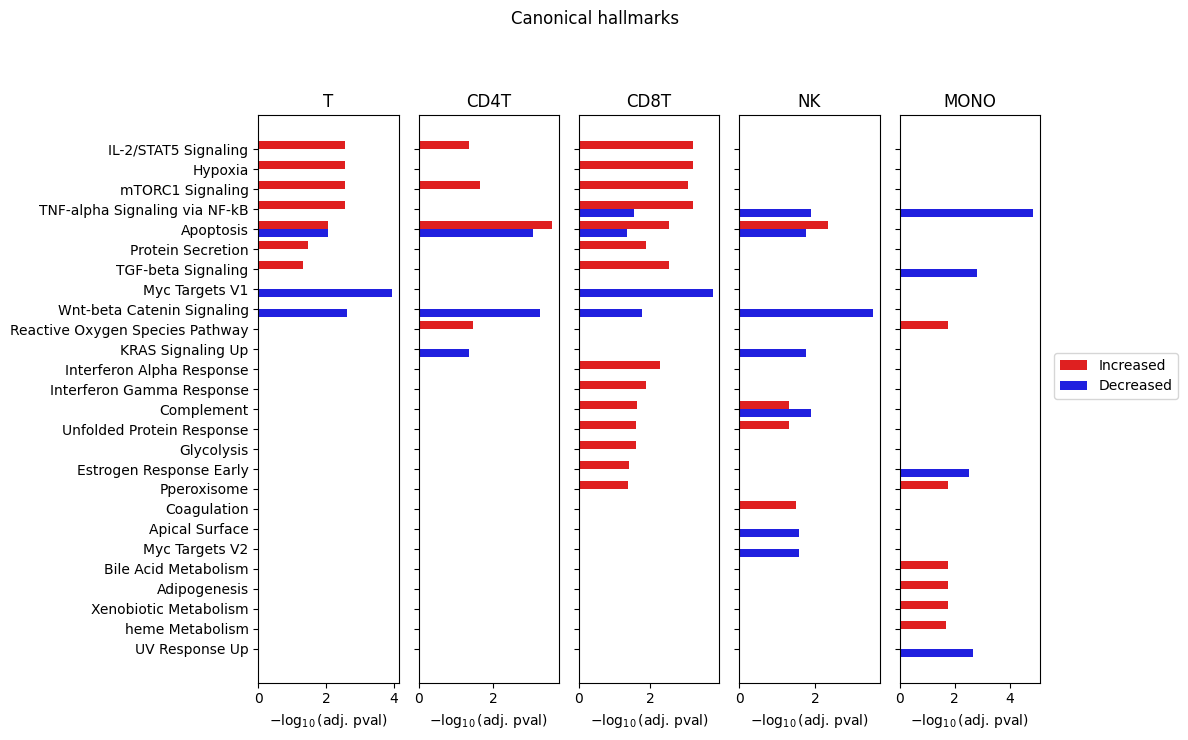

In [48]:
def plot_enrich(df, ax):
    # Compute -log10(Adjusted P-value)
    df["neg_log10_padj"] = -np.log10(df["Adjusted P-value"])

    # Set color mapping
    palette = {"Increased": "red", "Decreased": "blue"}

    # Create bar plot
    
    sns.barplot(
        data=df, 
        x="neg_log10_padj", 
        y="Term", 
        hue="linear_trend", 
        dodge=True,  # Ensures side-by-side bars
        palette=palette,
        ax=ax
    )
    ax.set_xlabel(r"$-\log_{10}$(adj. pval)")  
    ax.set_ylabel(r"")  
    ax.margins(y=.05)
celltypes = res2d_all['cell_type'].unique()
fig, axes = plt.subplots(1, len(celltypes), figsize=(12, 7), sharey=True)

for i, cell_type in enumerate(celltypes):
    mask = res2d_all['cell_type'] == cell_type
    res2d = res2d_all[mask]

    ax = axes[i]
    plot_enrich(res2d, ax)
    ax.set_title(f"""{cell_type}""")
    ax.legend().remove()
    
ax.legend(loc=(1.1, .5))
plt.suptitle('Canonical hallmarks', y=1.05)
plt.tight_layout()

# Collective trajectory

In [4]:
stats_df = stats_all[stats_all['cell_type'] == 'CD8T']
sig_tfs = stats_df[stats_df['meta_p_value'] < 0.05]['tf'].unique()
sig_tfs.shape

(149,)

In [23]:
# - subset for one dataset
tf_acts = tf_acts_dict[datasets[1]]
adata = tf_acts[:, tf_acts.var_names.isin(sig_tfs)]


# LOESS-fitted trajectories across age

In [ ]:
import numpy as np
import scipy.sparse as sp
from statsmodels.nonparametric.smoothers_lowess import lowess

def smooth_lowess(adata):
    # Ensure age is numeric
    age = adata.obs["age"].astype(float)
    # Sort indices by age for consistent smoothing
    age_sorted_idx = np.argsort(age)
    age_sorted = age.iloc[age_sorted_idx]
    X = adata.X 
    X_sorted = X[age_sorted_idx, :]

    # Apply LOESS smoothing for each gene
    smoothed_X_sorted = np.zeros_like(X_sorted)
    for i in range(X_sorted.shape[1]):  
        smoothed = lowess(X_sorted[:, i], age_sorted, frac=.2, return_sorted=False)  
        smoothed_X_sorted[:, i] = smoothed  

    # Revert back to original order
    smoothed_X = np.zeros_like(X)
    smoothed_X[age_sorted_idx] = smoothed_X_sorted  # Restore original order

    # Store in AnnData layers
    adata.layers["loess_smoothed"] = smoothed_X  # Convert back to sparse
smooth_lowess(adata)

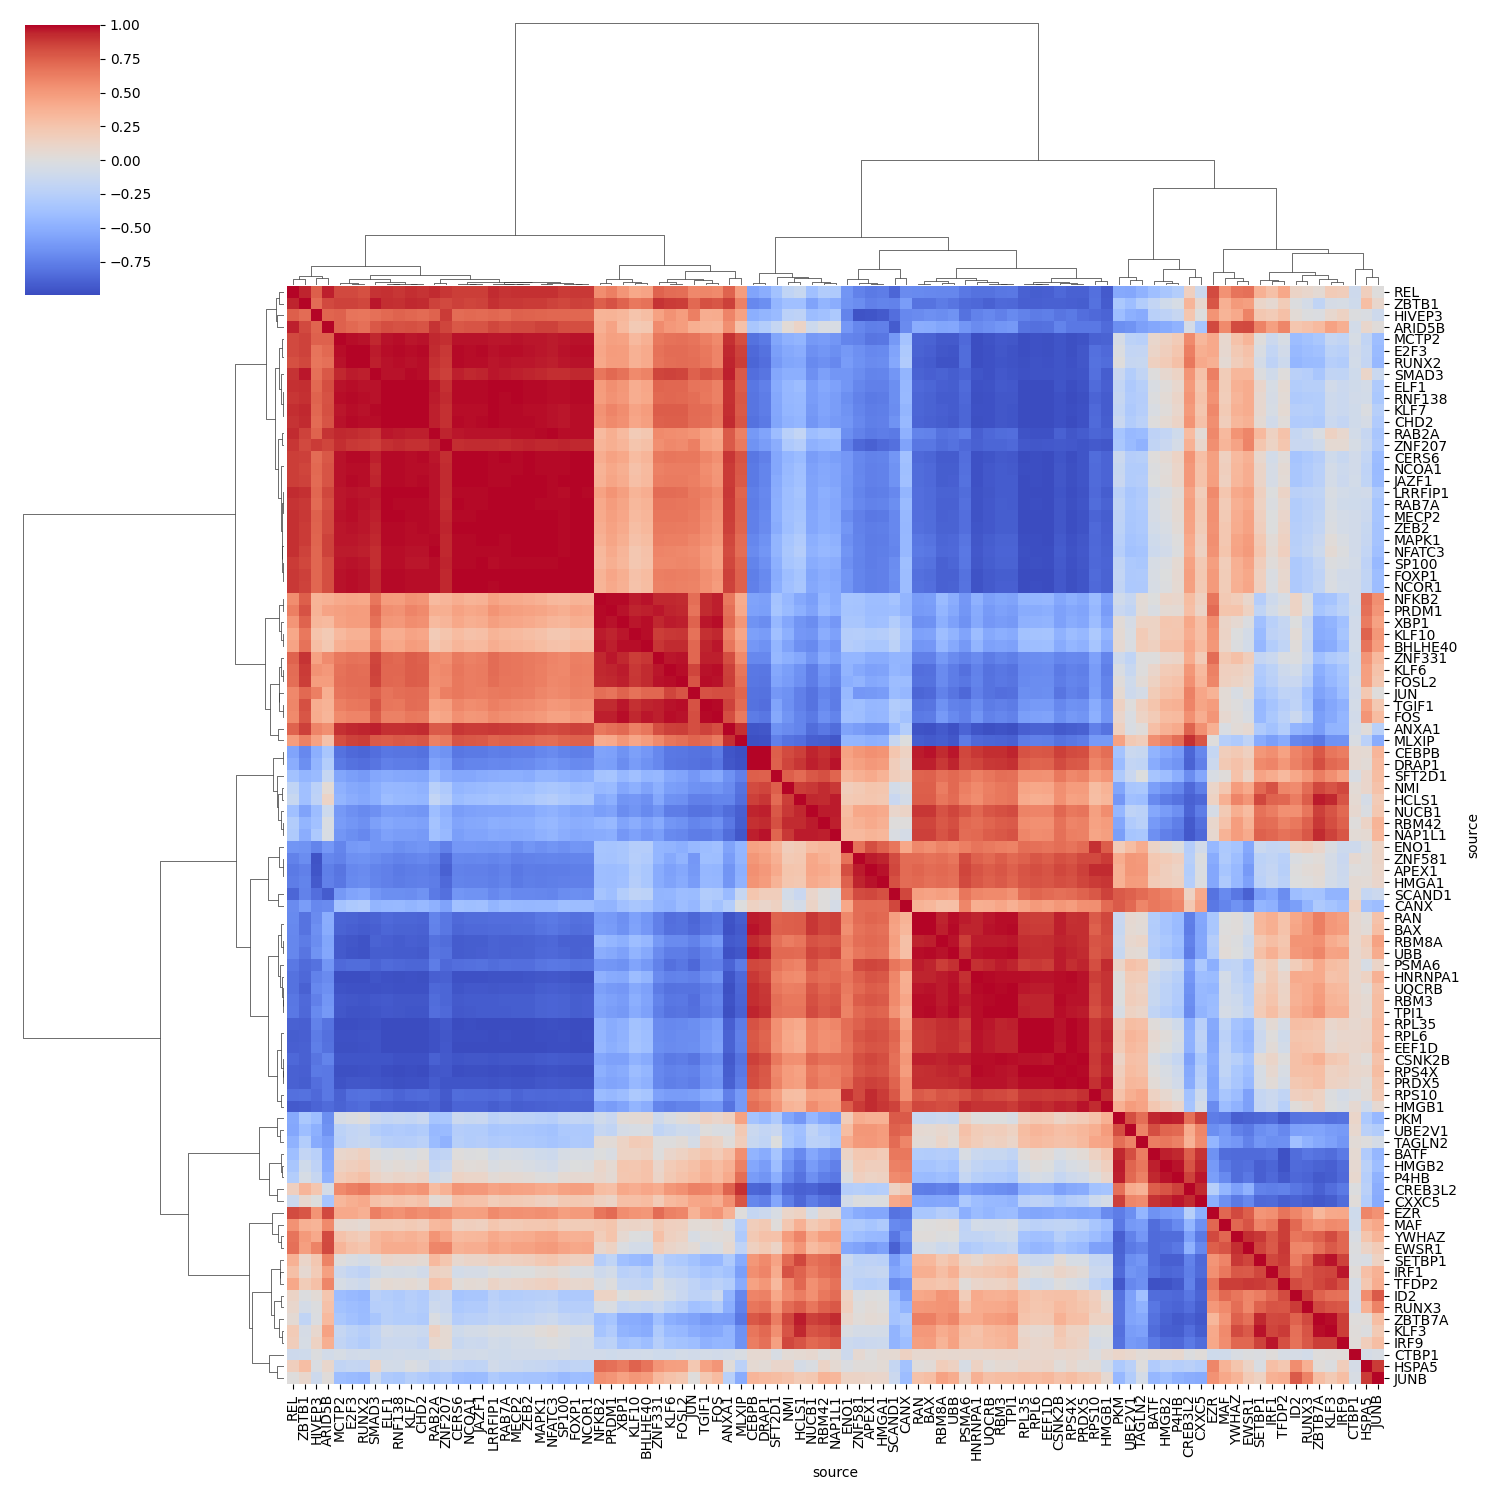

In [38]:
import scipy.cluster.hierarchy as sch

gene_expr = pd.DataFrame(adata.X.T, index=adata.var_names, columns=adata.obs_names)

# Compute gene-gene correlation
gene_corr = gene_expr.T.corr()

# Perform hierarchical clustering
linkage = sch.linkage(gene_corr, method="ward")

# Define a threshold to cut the dendrogram into a few clusters
num_clusters = 5  # Adjust based on visualization needs
clusters = sch.fcluster(linkage, num_clusters, criterion="maxclust")

# Sort genes by cluster
clustered_genes = gene_corr.index[np.argsort(clusters)]

# Reorder the correlation matrix
gene_corr_clustered = gene_corr.loc[clustered_genes, clustered_genes]

sns.clustermap(
    gene_corr_clustered, 
    cmap="coolwarm", 
    method="ward", 
    figsize=(15, 15),
    xticklabels=True, 
    yticklabels=True
)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Extract gene expression matrix
X = adata.X.T  # Transpose to get genes as rows

# Choose the number of clusters
k = 5  
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)

# Assign cluster labels to genes
adata.var["gene_cluster"] = kmeans.labels_

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Extract relevant data
# gene_clusters = adata.var["gene_cluster"].values  # Cluster assignments
# ages = adata.obs["age"].values  # Age variable
# X = adata.X  # Expression matrix (cells x genes)

# # Get unique ages and sort them
# unique_ages = np.sort(np.unique(ages))

# # Convert X to dense if it's sparse (for faster calculations)
# if not isinstance(X, np.ndarray):
#     X = X.toarray()

# # Loop through each cluster
# for cluster_id in np.unique(gene_clusters):
#     cluster_genes = np.where(gene_clusters == cluster_id)[0]  # Indices of genes in this cluster
    
#     # Extract expression data for genes in this cluster
#     expr_cluster = X[:, cluster_genes]

#     # Compute mean expression per age
#     mean_expr = np.array([expr_cluster[ages == age].mean(axis=0) for age in unique_ages])

#     # Plot individual genes (thin, transparent lines)
#     plt.figure(figsize=(8, 5))
#     for i in range(expr_cluster.shape[1]):  # Loop through genes
#         plt.plot(unique_ages, mean_expr[:, i], color="gray", alpha=0.3, lw=1)

#     # Plot mean expression across genes (thicker black line)
#     plt.plot(unique_ages, mean_expr.mean(axis=1), color="black", lw=2, label=f"Cluster {cluster_id} Mean")

#     # Formatting
#     plt.title(f"Expression Trends for Cluster {cluster_id}")
#     plt.xlabel("Age")
#     plt.ylabel("Expression Level")
#     plt.legend()
#     plt.show()